# Movies and Ratings Exploratory Data Analysis

Before using our dataset for a movie recommender system, we have to know all its characteristics, so in this jupyter notebook I will going to analyze it

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load the Movies Dataset

In [2]:
movies = pd.read_parquet('../data/raw/movies_metadata.parquet')
print(movies.shape)
movies.head().transpose()

(86242, 27)


,0,1,2,3,4
adult,False,False,False,False,False
backdrop_path,/fIWsCpYR9iGDMSbMTSAzy8L7Kg5.jpg,/jP8lHNHD89xaRPfAdyz5KEVYcSb.jpg,/xKsnZDERG1dk95wuZ5q9iks3OL3.jpg,/oMGV48EGhsNavC1PL8HMeWs5Udq.jpg,/3Rfvhy1Nl6sSGJwyjb0QiZzZYlB.jpg
belongs_to_collection,{'backdrop_path': '/dOSECZImeyZldoq0ObieBE0lwi...,None,{'backdrop_path': '/2rX05YZJJVoO1cgEnuvFsyU56Y...,None,{'backdrop_path': '/hApclyB9NEZEQujAVajzi5iWE4...
budget,60000000,0,60000000,58000000,30000000
genres,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...","[{'id': 10751, 'name': 'Family'}, {'id': 28, '...","[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...","[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...","[{'id': 10751, 'name': 'Family'}, {'id': 35, '..."
homepage,https://mgm.com/movies/goldeneye,,https://www.20thcenturystudios.com/movies/heat,,http://toystory.disney.com/toy-story
id,710,45325,949,11860,862
imdb_id,tt0113189,tt0112302,tt0113277,tt0114319,tt0114709
origin_country,[GB],[US],[US],[US],[US]
original_language,en,en,en,en,en


In [3]:
movies.columns

Index(['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres',
       'homepage', 'id', 'imdb_id', 'origin_country', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'movieId'],
      dtype='object')

We have 86,242 movies and 27 of it's features:

- __id__: The TMDB ID of the movie.
- __adult__: Indicates if the movie is X-Rated or Adult.
- __belongs_to_collection__: A stringified dictionary that gives information on the movie series the particular film belongs to.
- __budget__: The budget of the movie in dollars.
- __genres__: A stringified list of dictionaries that list out all the genres associated with the movie.
- __homepage__: The Official Homepage of the movie.
- __imdb_id__: The IMDB ID of the movie.
- __original_language__: The language in which the movie was originally shot in.
- __original_title__: The original title of the movie.
- __overview__: A brief blurb of the movie.
- __popularity__: The Popularity Score assigned by TMDB.
- __poster_path__: The URL of the poster image.
- __production_companies__: A stringified list of production companies involved with the making of the movie.
- __production_countries__: A stringified list of countries where the movie was shot/produced in.
- __release_date__: Theatrical Release Date of the movie.
- __revenue__: The total revenue of the movie in dollars.
- __runtime__: The runtime of the movie in minutes.
- __spoken_languages__: A stringified list of spoken languages in the film.
- __status__: The status of the movie (Released, To Be Released, Announced, etc.)
- __tagline__: The tagline of the movie.
- __title__: The Official Title of the movie.
- __video__: Indicates if there is a video present of the movie with TMDB.
- __vote_average__: The average rating of the movie.
- __vote_count__: The number of votes by users, as counted by TMDB.
- __backdrop_path__: The URL of the backdrop poster image.
- __origin_country__: The country were the movie was released.
- __movie_id__: The inner id of the movie

In [4]:
# Lets delete the features that are not important
movies = movies.drop(columns=['homepage', 'imdb_id', 'original_language', 'overview', 'poster_path',
       'production_countries', 'spoken_languages', 'status', 'tagline', 'video', 'backdrop_path', 'movieId'])
# Data Types
movies.dtypes

adult                       bool
belongs_to_collection     object
budget                     int64
genres                    object
id                         int64
origin_country            object
original_title            object
popularity               float64
production_companies      object
release_date              object
revenue                    int64
runtime                    int64
title                     object
vote_average             float64
vote_count                 int64
dtype: object

## ID

Lets verify that we do not have duplicated values for the ID column

In [5]:
movies[movies.duplicated('id')]['id'].count()

np.int64(0)

We do not have duplicated id's

## Adults

Let's see how many movies are clasified as adults

In [6]:
movies['adult'].value_counts()

adult
False    86219
True        23
Name: count, dtype: int64

We have only 23 movies clasified as adults, so this column does not contribute anything

## Belongs to Collection

As the values for this column are stringified, we will extract the collection, if it has

In [7]:
movies['belongs_to_collection'].value_counts()[:5]

belongs_to_collection
{'backdrop_path': '/foe3kuiJmg5AklhtD3skWbaTMf2.jpg', 'id': 415931.0, 'name': 'The Bowery Boys Collection', 'poster_path': '/q6sA4bzMT9cK7EEmXYwt7PNrL5h.jpg'}                48
{'backdrop_path': '/otuz9DuwbQn5KBW5zDxund7ifiU.jpg', 'id': 279715.0, 'name': 'Beck Collection', 'poster_path': '/8Kzrc2bsGt0RUyTN6vHvh4yu0QO.jpg'}                           42
{'backdrop_path': '/vJ7E00tvsGQIRMGeyLk2UHT39dH.jpg', 'id': 1418563.0, 'name': '100 Years of Olympic Films: 1912–2012', 'poster_path': '/5EfKkyTnmQ1uOp8POjSyTHqesEP.jpg'}    40
{'backdrop_path': '/yxe3ntTL3WVKLDm9h2RQlN1njuY.jpg', 'id': 123588.0, 'name': 'Os Trapalhões: Coleção', 'poster_path': '/ug34Rv1iINCnXbHFLLdg9yXSFsC.jpg'}                    39
{'backdrop_path': '/ub2Fqc2HD1rhuxNiEROymNrTdHO.jpg', 'id': 284326.0, 'name': 'Wallander Collection', 'poster_path': '/zJoSKFH2hAmLU0lnDujtQV6iwuv.jpg'}                      32
Name: count, dtype: int64

In [8]:
## How many movies belongs to a collection
movies['belongs_to_collection'].notna().sum()

np.int64(9520)

Around 11% of the movies belong to a collection. Although this feature could provide valuable information for our recommender system, the number of films in a collection is quite small. Therefore, we will remove this column.

For now, let's explore the 10 collections tha have more films.

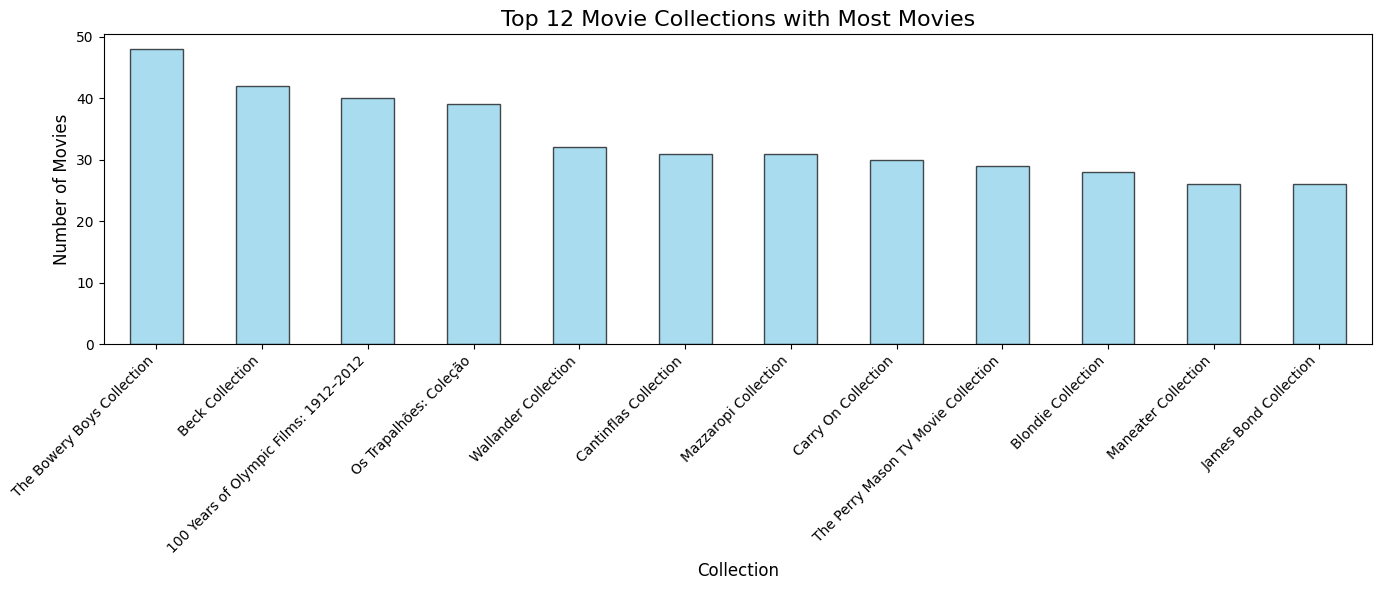

In [9]:
movies['belongs_to_collection'] = movies['belongs_to_collection'].apply(lambda x: x['name'] if isinstance(x, dict) else np.nan)
collection_counts = movies[movies['belongs_to_collection'].notna()]['belongs_to_collection'].value_counts()

# Select the 12 collections with most movies
top_collections = collection_counts.head(12)

plt.figure(figsize=(14,6))
top_collections.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Top 12 Movie Collections with Most Movies', fontsize=16)
plt.xlabel('Collection', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

To be honest, the only collection I'm familiar with is James Bond, so I can't provide any insights about the others.

## Budget
Let´s explore the budget column

In [10]:
movies[movies['budget'] == 0].shape

(70063, 15)

Almost 90% of the movies do not have information about their budget, but lets see the highest budgets of the movies that have this information.

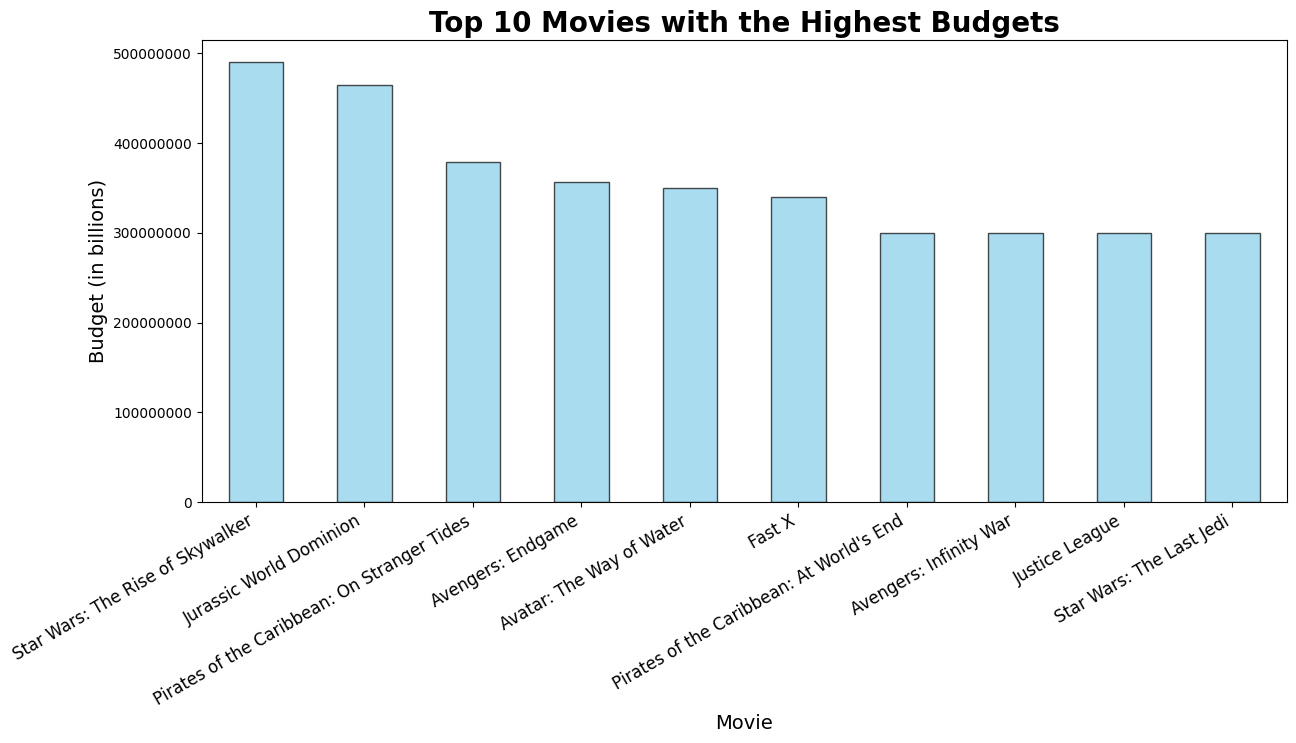

In [11]:
# Top 10 movies witht the highest budget
top_budget = movies.sort_values(by='budget', ascending=False)[['title', 'budget']].head(10)
ax = top_budget.plot(kind='bar', x='title', y='budget', color='skyblue', edgecolor='black', alpha=0.7, legend=False)

# Plot them
fig = plt.gcf() 
fig.set_size_inches(14, 6)  
plt.title("Top 10 Movies with the Highest Budgets", fontsize=20, fontweight='bold')
plt.xlabel("Movie", fontsize=14)
plt.ylabel("Budget (in billions)", fontsize=14)

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.show()

Ten out of the ten movies with the highest budgets belong to the action genre, with the majority being science fiction, such as *Star Wars* and *Avatar*. This suggests that producing these types of films tends to be the most expensive compared to other genres.

## Original Title vs Title

We do not have null values for the titles columns, so lets compare both columns

In [12]:
movies[movies['original_title'] != movies['title']][['original_title', 'title']]

,original_title,title
27,摇啊摇，摇到外婆桥,Shanghai Triad
32,La Cité des enfants perdus,The City of Lost Children
58,Le Confessionnal,The Confessional
61,Il postino,The Postman
65,Gazon maudit,French Twist
...,...,...
86232,三贵情史,Flaming Cloud
86236,Duell am Abgrund,Race to the Summit
86237,Zwischen den Jahren,End of the Season
86239,El caso Monroy,The Monroy Affaire


## Genres

Let's change the data type of the genres from json to a list containing only the genres, so we can explore them

In [13]:
movies['genres'] = movies['genres'].apply(lambda x: [item['name'] for item in x])
movies['genres'].head()

0             [Adventure, Action, Thriller]
1        [Family, Action, Adventure, Drama]
2                    [Crime, Drama, Action]
3                  [Romance, Drama, Comedy]
4    [Family, Comedy, Animation, Adventure]
Name: genres, dtype: object

Now let's check the movies that do not have genre

In [14]:
#  Null values
movies[movies['genres'].apply(lambda x: len(x) == 0)].shape[0]

736

We have 736 films without genre, so I will remove them, since this is a very important feature for a recommender system

In [15]:
movies = movies.drop(movies[movies['genres'].apply(lambda x: len(x) == 0)].index)
movies.shape

(85506, 15)

Let's see all the genres we have and the count for each one

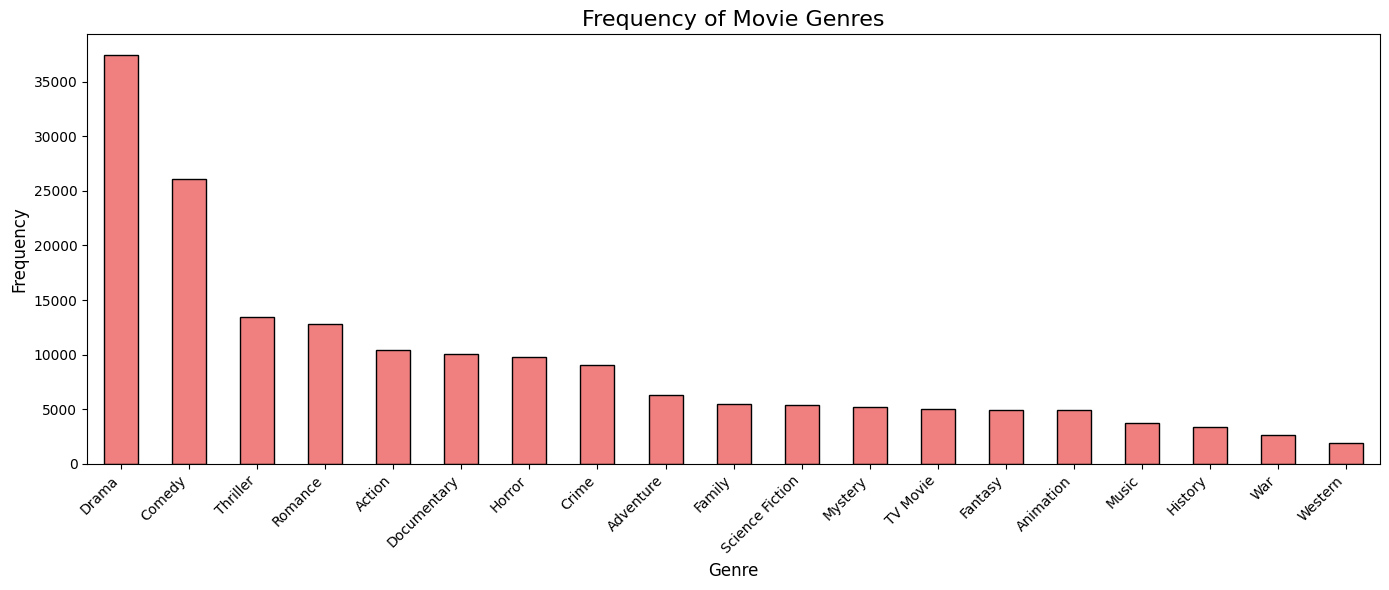

In [16]:
# Genres list
genres = pd.Series([genre for sublist in movies['genres'] for genre in sublist])
# Count the frequency of each genre
genre_counts = genres.value_counts()

# Create a bar chart for the genre counts
plt.figure(figsize=(14, 6))  
genre_counts.plot(kind='bar', color='lightcoral', edgecolor='black') 

# Add title and labels for the axes
plt.title('Frequency of Movie Genres', fontsize=16)  
plt.xlabel('Genre', fontsize=12)  
plt.ylabel('Frequency', fontsize=12) 

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As we can see, the most popular genres are Drama and Comedy, with approximately 35,000 and 25,000 films, respectively. On the other hand, the least popular genres are History, War, Western, and Foreign, each with fewer than 5,000 films.

It's important to note that when a film contains multiple genres, such as Drama and Comedy, it is counted once for each genre.

## Production Companies

This can be a very helpul feature for our recommender system, since many people watch movies that are produced by similar companies

As we can see a movie can be produced by multiple companies; also the movies are in a json format, so lets extract the companies

In [17]:
movies['production_companies'] = movies['production_companies'].apply(lambda x: [item['name'] for item in x])
movies[['production_companies']]

,production_companies
0,[EON Productions]
1,"[Walt Disney Pictures, Painted Fence Productions]"
2,"[Warner Bros. Pictures, Regency Enterprises, F..."
3,"[Paramount Pictures, Constellation Films, Mira..."
4,[Pixar]
...,...
86237,"[Radical Movies Production, ARTE, WDR, ARD]"
86238,"[Emerald Caz Productions, Legendary Goat Produ..."
86239,"[Chullachaki Producciones, Gema Films]"
86240,"[Andisheh Pardis Jam, Katara Studios]"


Now lets check the movies that do not have a production company

In [18]:
sum(not row for row in movies['production_companies'])

9782

In [19]:
# Replace the empty lists for null values
movies['production_companies'] = movies['production_companies'].apply(lambda x: np.nan if not x else x)
movies['production_companies'].isnull().sum()

np.int64(9782)

In [20]:
movies.shape

(85506, 15)

In [21]:
movies[movies['production_companies'].isna()].sort_values(by='popularity', ascending=False)[['title', 'popularity']].head(10)

,title,popularity
76879,Naked Poison,7.5272
13879,Top Dog,4.7421
70382,Do You Know Me,4.6544
42754,You Cast A Spell On Me,4.0228
50264,The Tit and the Moon,4.0186
42932,Girl in the Box,3.8427
73889,Snake In The Eagles Shadow 2,3.4847
80822,One Week Friends,3.4415
72222,The Actor,3.3763
75072,The Unhealer,3.3528


About 12% of the films do not have data from the company that produce them. This can be a useful feature for our recommendation system, so we will leave this feature and we can do the following:

- Fill the nan values with 'unkwon'
- Change the production-companies feature to 'has_company'
- Delete it, if it is not important for the model

### Most Famous Production Companies

Now let's take a look to the most famous production companies

In [22]:
# Create a row per production Company
production = movies.explode('production_companies')
# Group By Production Company
production = production.groupby(by='production_companies').agg(
    total_popularity = ('popularity', 'mean'),
    total_revenue = ('revenue', 'sum'),
    movies_produced = ('title', 'count')
).reset_index()

production.head()

,production_companies,total_popularity,total_revenue,movies_produced
0,"""DIA"" Productions GmbH & Co. KG",2.7482,44350926,1
1,"""G"" P.C. S.A.",0.4906,1702603,1
2,"""GREEN"" Productions",0.7433,0,1
3,"""Gansakhkomi""",0.2452,0,1
4,"""Weathering With You"" Film Partners",9.8505,192729404,1


#### Companies that have more popularity in average per movie produced

As there can be production companies that have 1 or 2 released films with high popularity, I'll consider only the production companies that have released more than 15 films.

In [23]:
production[production['movies_produced'] > 15].sort_values(by='total_popularity', ascending=False).head(10)

,production_companies,total_popularity,total_revenue,movies_produced
20366,Illumination,13.276126,9443073804,35
26898,Marvel Studios,12.119127,30197109034,51
19283,Heyday Films,10.179262,13895016127,29
26892,Marvel Entertainment,9.683714,11446029852,28
17162,Genre Films,8.592972,6369596652,18
46571,WingNut Films,8.152814,7231237746,21
24187,Legendary Pictures,7.881949,16324105277,61
38640,Skydance Media,7.224618,8715050575,33
100,1492 Pictures,7.197685,6119978810,26
31578,Pacific Data Images,6.887806,5270757669,17


#### Companies that have more produced films

In [24]:
production.sort_values(by='movies_produced', ascending=False).head(10)

,production_companies,total_popularity,total_revenue,movies_produced
45913,Warner Bros. Pictures,2.058140,72405344092,1632
27595,Metro-Goldwyn-Mayer,1.267483,21386806323,1631
31953,Paramount Pictures,2.087514,56525696154,1292
9510,Columbia Pictures,2.298402,58268650644,1210
44594,Universal Pictures,2.699703,71763408779,1208
178,20th Century Fox,2.087660,59097936626,1176
7275,Canal+,1.026195,2090460438,534
45833,Walt Disney Productions,0.846064,3199318492,530
44499,United Artists,1.608057,6123635235,525
34493,RKO Radio Pictures,0.749347,203666614,504


#### Companies with the highest revenues

In [25]:
production.sort_values(by='total_revenue', ascending=False).head(10)

,production_companies,total_popularity,total_revenue,movies_produced
45913,Warner Bros. Pictures,2.058140,72405344092,1632
44594,Universal Pictures,2.699703,71763408779,1208
178,20th Century Fox,2.087660,59097936626,1176
9510,Columbia Pictures,2.298402,58268650644,1210
31953,Paramount Pictures,2.087514,56525696154,1292
45831,Walt Disney Pictures,3.684726,34986783160,254
26898,Marvel Studios,12.119127,30197109034,51
29669,New Line Cinema,3.632764,27535840030,339
27595,Metro-Goldwyn-Mayer,1.267483,21386806323,1631
2165,Amblin Entertainment,4.766932,19994023246,101


In [26]:
## Delete the variable to free memory
del production

## Release Date 

We will not include this column in the system, but we will use for now to explore the release years of the movies

In [27]:
year = pd.to_datetime(movies['release_date'], errors='coerce')
year = year[year.notnull()].dt.year
print(f'The oldest movie the dataset has, was released in: {year.min()}')
print(f'The latest movie the dataset has, was released in: {year.max()}')

The oldest movie the dataset has, was released in: 1874
The latest movie the dataset has, was released in: 2026


<Axes: >

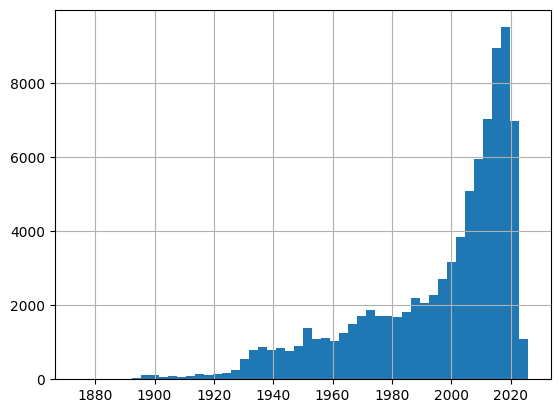

In [28]:
year.hist(bins=50)

As we can see we have films from 1874 to 2026, but the range were we have a considered amount of films is from 1995 to 2022. Since the dataset was released in 2023, but there may be some wrong values.

Let's get deeper.

In [29]:
year[year > 1995].count()

np.int64(54234)

Approximately 65% of the dataset is from 1995 to 2017. 

For the recommender system, we can discard movies released before 1995 and retain only the most popular movies released before 1995.

In [30]:
# Years with more films released
year_count = year.value_counts()
year_count.head(10)

release_date
2017    3234
2018    3172
2016    3108
2019    3091
2015    3002
2014    2840
2013    2557
2020    2478
2021    2357
2012    2330
Name: count, dtype: int64

As we can see the years were a lot of movies were released are from 2010 to the present.

## Popularity 

Let's remember that popularity reffers to a score of popularity assigned by TMDB, which we do not know how this score was obtained.

In [31]:
# First we have to cast the data type from string to float
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce') 
movies['popularity'].notnull().sum(), movies.shape[1]

(np.int64(85506), 15)

Let's explore its distribution

In [32]:
movies['popularity'].describe()

count    85506.000000
mean         1.074441
std          2.160695
min          0.000000
25%          0.382900
50%          0.665200
75%          1.146500
max        339.006700
Name: popularity, dtype: float64

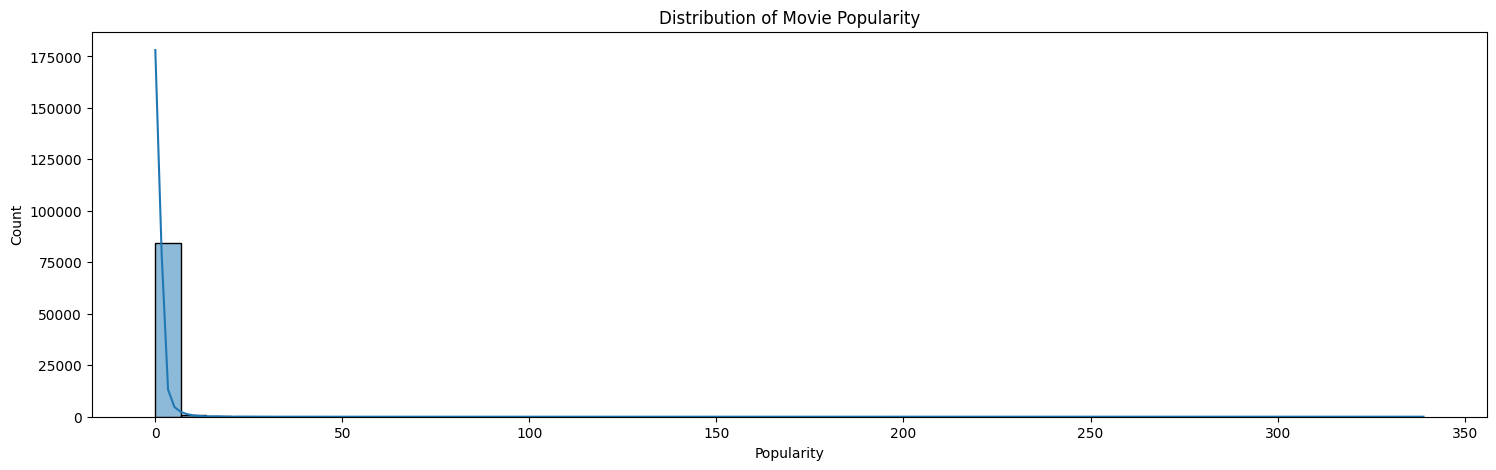

In [33]:
plt.figure(figsize=(18,5))
sns.histplot(movies['popularity'], bins=50, kde=True)
plt.xlabel('Popularity')
plt.title('Distribution of Movie Popularity')
plt.show()

We can see that the distribution is extremely skewed, almost all movies have a popularity score less than 3, with a mean of 1.46 and the 75% under 1.94. So we expect that the normal values of popularity is around 0 and 2.

Let's check the 15 most populars movies

In [34]:
movies.sort_values(by='popularity', ascending=False)[['title', 'popularity']].head(15)

,title,popularity
84307,The Super Mario Bros. Movie,339.0067
7169,The Passion of the Christ,133.5792
75694,Starbright,129.5440
10790,The Devil Wears Prada,83.9444
85323,Rocky Aur Rani Kii Prem Kahaani,80.1872
77464,Spider-Man: No Way Home,72.5512
20985,Interstellar,65.7255
49686,Star Wars: The Last Jedi,55.2965
16952,The Avengers,54.9842
5385,xXx,54.7932


I only recognize half the list, and honestly I dont think that the movies mentioned above are the most populars, so we have to investigate how TMDB assign the popularity score to the movies.

## Vote Count

In [35]:
movies['vote_count'].describe()

count    85506.000000
mean       283.293219
std       1320.786406
min          0.000000
25%         10.000000
50%         26.000000
75%         89.000000
max      39350.000000
Name: vote_count, dtype: float64

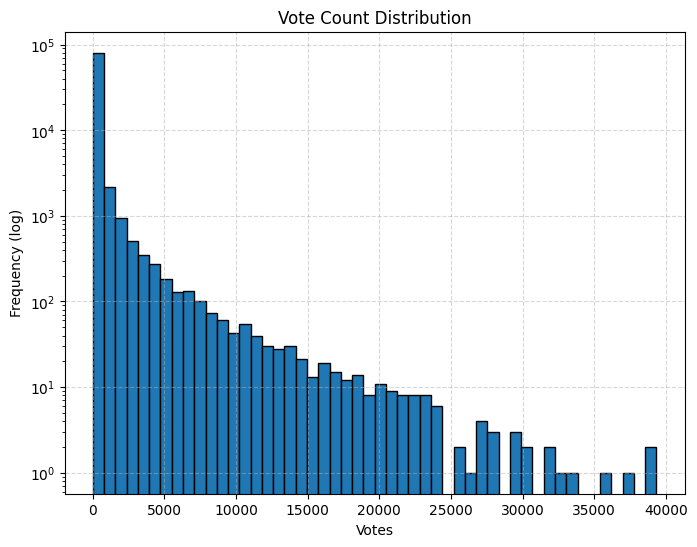

In [36]:
plt.figure(figsize=(8,6))
plt.hist(movies['vote_count'], bins=50, edgecolor='black', log=True)
plt.xlabel("Votes")
plt.ylabel("Frequency (log)")
plt.title("Vote Count Distribution")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

As with popularity, the distribution is extremely skewed, the mean (272.30) is much higher than the median (24), most of the films have few votes, but there are some with thousands of votes that increase the mean. Half of the films have 24 votes or less. This indicates that most of the films have few votes.

Now lets see the most voted films

This suggests that a small number of items are very popular, while the majority receive relatively few votes.

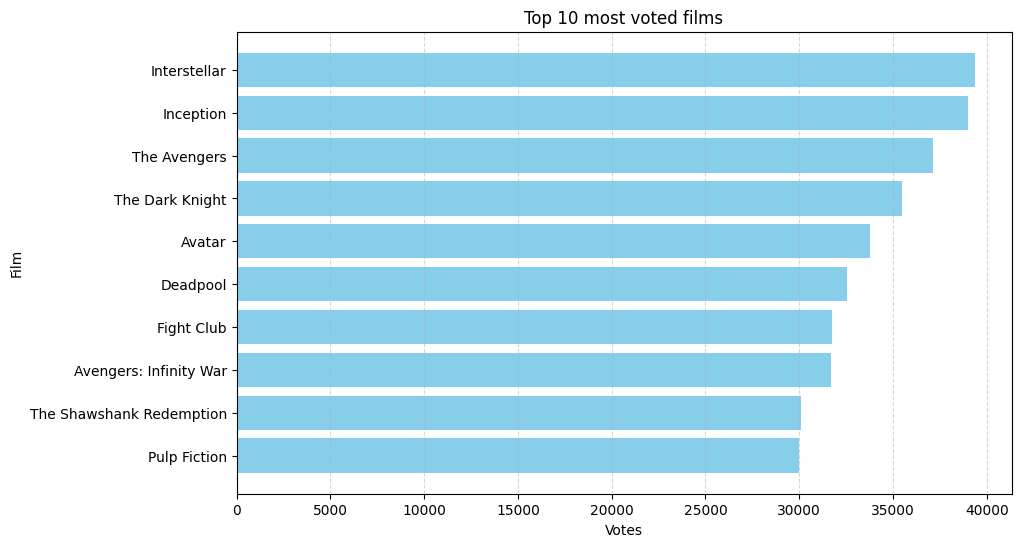

In [37]:
top_movies = movies.nlargest(10, 'vote_count')

plt.figure(figsize=(10,6))
plt.barh(top_movies['title'], top_movies['vote_count'], color='skyblue')
plt.xlabel("Votes")
plt.ylabel("Film")
plt.title("Top 10 most voted films")
plt.gca().invert_yaxis()  #
plt.grid(axis='x', linestyle="--", alpha=0.5)
plt.show()

From this list I can recognize all the movies so I think it is more important the *vote_count* column than the *popularity* one for the recommender system.

## Vote Average

In [38]:
# Discard the movies with no votes
votes = movies[movies['vote_count'] > 0]
votes['vote_average'].describe()

count    84105.000000
mean         5.924782
std          1.202115
min          0.000000
25%          5.200000
50%          6.042000
75%          6.746000
max         10.000000
Name: vote_average, dtype: float64

It seems that the vote average is normalized between 0 and 10, as we can see the mean is almost 6, the standard deviation is relatively low (1.17) and 75% of the movies have a rating of 6.8 or lower

<Axes: ylabel='Density'>

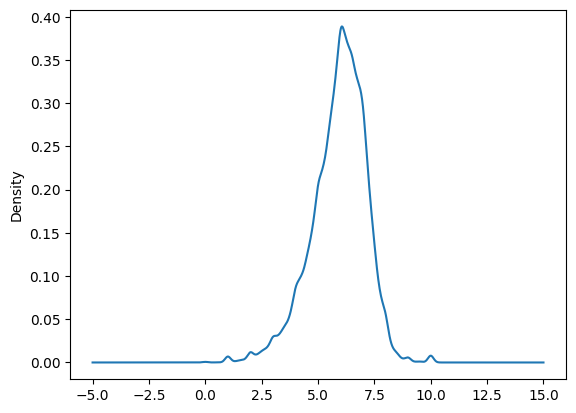

In [41]:
votes['vote_average'].plot(kind='kde')

The distribution appears to be unimodal and slightly skewed to the left, with most ratings concentrated between 5 and 7. The peak suggests that the majority of ratings are around 6, indicating that most movies receive average to slightly above-average scores. There are very few ratings below 3 or above 9, suggesting that extreme ratings are less common.

Now let's select the films with highest ratings but only if they have more than 1,500 votes

In [42]:
votes = movies[movies['vote_count'] > 1500]
votes.sort_values(by='vote_average', ascending=False)[['title', 'vote_average', 'vote_count', 'popularity']].head(15)

,title,vote_average,vote_count,popularity
313,The Shawshank Redemption,8.718,30088,41.1463
833,The Godfather,8.687,22736,39.2262
1185,The Godfather Part II,8.572,13775,22.3481
521,Schindler's List,8.567,17300,21.5504
1168,12 Angry Men,8.559,9883,17.2448
5482,Spirited Away,8.533,18149,30.1776
12165,The Dark Knight,8.528,35465,34.1491
10132,Dilwale Dulhania Le Jayenge,8.515,4572,11.6293
3038,The Green Mile,8.505,19057,22.4205
7001,The Lord of the Rings: The Return of the King,8.496,26305,25.4461


Are popularity, vote_count and vote_average related each other?

In [43]:
movies[['vote_count', 'popularity', 'vote_average']].corr()

,vote_count,popularity,vote_average
vote_count,1.000000,0.607241,0.158268
popularity,0.607241,1.000000,0.159720
vote_average,0.158268,0.159720,1.000000


As we can see, popularity and vote count are very correlated, while vote average appears to be slightly correlated.

## Runtime

Now we will explore the average runtime of the films

In [44]:
movies['runtime'].describe()

count    85506.000000
mean        91.858174
std         53.135979
min          0.000000
25%         84.000000
50%         93.000000
75%        105.000000
max      12480.000000
Name: runtime, dtype: float64

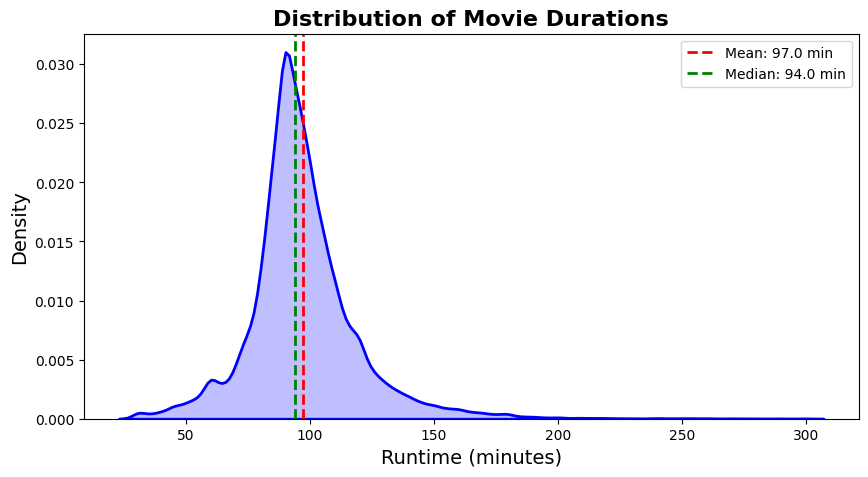

In [45]:
plt.close('all')

# Delete outliers
filtered_runtime = movies['runtime'].dropna()  # Delete NaN
filtered_runtime = filtered_runtime[(filtered_runtime >= 30) & (filtered_runtime <= 300)]

# Plot the runtimes
plt.figure(figsize=(10, 5))
sns.kdeplot(filtered_runtime, fill=True, color='blue', linewidth=2)

# Add the mean and median
mean_runtime = filtered_runtime.mean()
median_runtime = filtered_runtime.median()
plt.axvline(mean_runtime, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_runtime:.1f} min')
plt.axvline(median_runtime, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_runtime:.1f} min')

# Add the title and legends
plt.title("Distribution of Movie Durations", fontsize=16, fontweight='bold')
plt.xlabel("Runtime (minutes)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.show()


Most movies have a runtime between 1 and 2 hours, with an average of 91.8 minutes and a median of 93 minutes. Additionally, 75% of films have a runtime of less than 105 minutes. However, the maximum runtime reaches 12,480 minutes equivalent to approximately 20 hours.

## Origin Country

Finally, let's explore the 'origin country' column to analyze the countries that produce and release movies.

In [46]:
# Extract the countries, since they are stored as a list
countries = movies['origin_country'].dropna()
countries = countries.explode()
# Count the frequency of country
country_counts = countries.value_counts()[:10]
country_counts

origin_country
US    48536
GB     7282
FR     5619
CA     3779
IT     3668
JP     3014
DE     2494
IN     2318
ES     1889
RU     1202
Name: count, dtype: int64

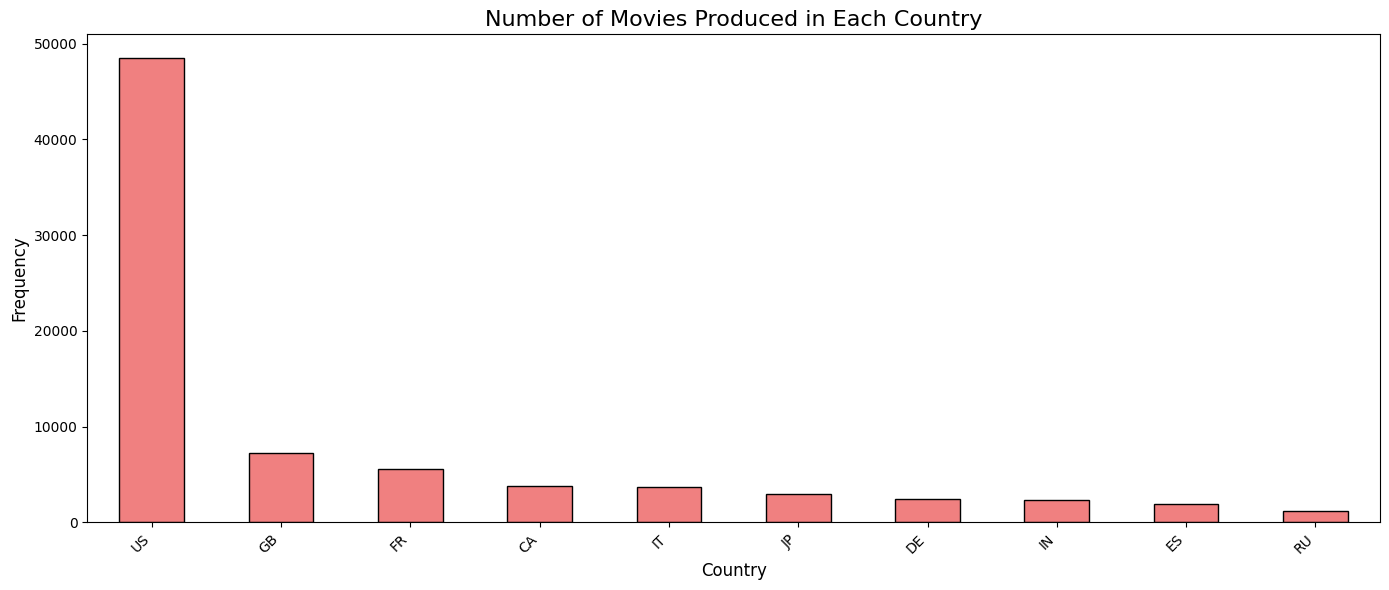

In [47]:
plt.close('all')

# Create a bar chart for the countries
plt.figure(figsize=(14, 6))  
country_counts.plot(kind='bar', color='lightcoral', edgecolor='black') 

# Add title and labels for the axes
plt.title('Number of Movies Produced in Each Country', fontsize=16)  
plt.xlabel('Country', fontsize=12)  
plt.ylabel('Frequency', fontsize=12) 

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As expected, the United States dominates film production with nearly 50,000 movies, far outpacing other countries. Following behind are Great Britain, France, and Canada, contributing with approximately 20,000 films. The middle tier includes Italy, Japan, and Denmark, each with around 1,500 productions each one. Completing the top ten are India, Spain, and Honk Kong, each responsible for roughly 1,000 films. This distribution clearly illustrates the disproportionate influence of American cinema on the global film industry